In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [18]:
xtrain = pd.read_csv("data/xtrain.csv")
xtest = pd.read_csv("data/xtest.csv")
ytrain = pd.read_csv("data/ytrain.csv")
ytest = pd.read_csv("data/ytest.csv")

In [19]:
std_scaler = StandardScaler()

In [20]:
xtrain = std_scaler.fit_transform(xtrain)
xtest = std_scaler.transform(xtest)

In [21]:
xtrain

array([[-1.58410418, -0.53538629, -0.47451561, ..., -0.31720529,
         0.61908681, -1.40530972],
       [ 0.8122747 , -0.57258668,  0.38178033, ..., -0.31720529,
        -1.61528235, -1.40530972],
       [ 0.8122747 ,  0.20862144, -0.47451561, ..., -0.31720529,
         0.61908681,  0.71158691],
       ...,
       [-1.58410418,  1.39903383, -0.47451561, ..., -0.31720529,
         0.61908681, -1.40530972],
       [ 0.8122747 , -0.60978707,  1.23807626, ..., -0.31720529,
         0.61908681, -1.40530972],
       [ 0.8122747 ,  0.28302222, -0.47451561, ..., -0.31720529,
         0.61908681,  0.71158691]], shape=(711, 8))

In [22]:
model = Sequential()

model.add(Dense(input_dim=8, kernel_initializer='he_normal',activation='relu',units=6))
model.add(Dropout(0.1))

model.add(Dense(kernel_initializer='he_normal',activation='relu',units=8))
model.add(Dropout(0.2))

model.add(Dense(kernel_initializer='he_normal',activation='relu',units=7))
model.add(Dropout(0.1))

model.add(Dense(kernel_initializer='he_normal',activation='sigmoid',units=1))

In [23]:
model

<Sequential name=sequential_3, built=True>

In [24]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │            63 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(xtrain,ytrain,validation_split=0.2,epochs=50,batch_size=5)

Epoch 1/50


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6074 - loss: 0.6775 - val_accuracy: 0.6364 - val_loss: 0.6347
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6338 - loss: 0.6342 - val_accuracy: 0.6853 - val_loss: 0.6215
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6426 - loss: 0.6190 - val_accuracy: 0.6853 - val_loss: 0.6111
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6532 - loss: 0.6183 - val_accuracy: 0.7203 - val_loss: 0.6047
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6585 - loss: 0.6054 - val_accuracy: 0.7203 - val_loss: 0.5958
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6743 - loss: 0.6032 - val_accuracy: 0.7273 - val_loss: 0.5876
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7007 - loss: 0.5954 - val_accuracy: 0.7343 - val_loss: 0.5723
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6866 - loss: 0.5707 - val_accuracy: 0.7343 - val_

In [28]:
model.save("titanic_ann_model.h5")

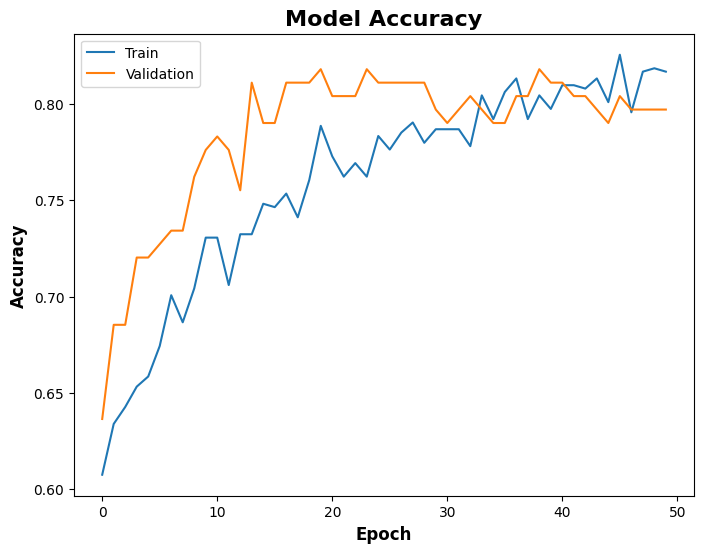

In [35]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy',fontsize=16,weight='bold')
plt.xlabel('Epoch',fontsize=12,weight='bold')
plt.ylabel('Accuracy',fontsize=12,weight='bold')
plt.legend(['Train','Validation'])
plt.show()

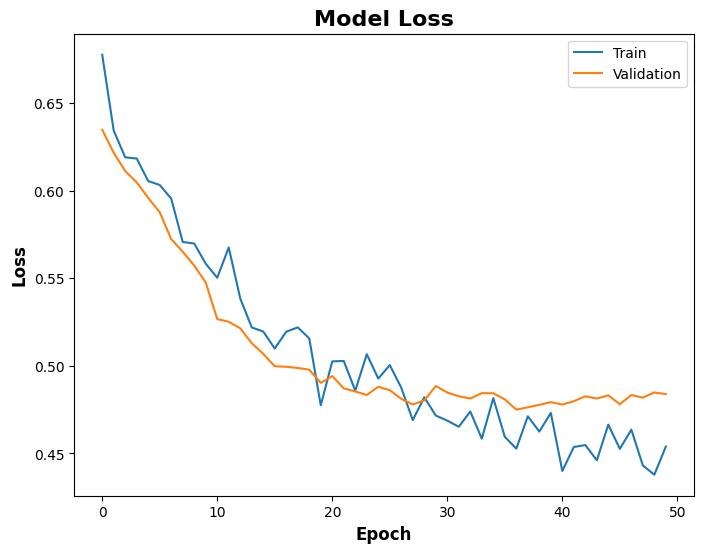

In [36]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss',fontsize=16,weight='bold')
plt.xlabel('Epoch',fontsize=12,weight='bold')
plt.ylabel('Loss',fontsize=12,weight='bold')
plt.legend(['Train','Validation'])
plt.show()